# Walmart Store Sales — engineered XGBoost experiment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MLfinal/Walmart-Recruiting---Store-Sales-Forecasting/blob/dev/models/tree_based/xgboost/model_experiment_XGBoost.ipynb)

This notebook extends `baseline_xgboost.ipynb` with the feature families documented for the LightGBM experiment, chronological validation, Optuna tuning, and extensive Weights & Biases tracking.

Important leakage rule: short target lags (`lag_1`, `lag_4`, `lag_13`) are not used because the Kaggle test set is a 39-week multi-step horizon. `lag_52` is safe here: every validation/test value comes from already observed history. Training target aggregates are shifted expanding statistics; validation/test aggregates are learned only from their historical training partition.

The notebook is intentionally saved without outputs. In Colab, select a GPU runtime, set `WANDB_API_KEY` in Colab Secrets, update `DATA_DIR` if necessary, and run all cells.

In [54]:
%pip install -q "xgboost>=3.0,<4" "wandb>=0.19,<1" "optuna>=4.0,<5" "joblib>=1.4,<2" "cloudpickle>=3.0,<4"

In [55]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [56]:
from __future__ import annotations

import json
import math
import os
import platform
import random
import subprocess
import sys
import uuid
from pathlib import Path

import joblib
import cloudpickle
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import sklearn
import wandb
import xgboost as xgb
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from wandb.integration.xgboost import WandbCallback

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option("display.max_columns", 120)

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgb.__version__,
    "optuna": optuna.__version__,
    "wandb": wandb.__version__,
})

{'python': '3.12.13', 'pandas': '2.2.2', 'scikit_learn': '1.6.1', 'xgboost': '3.3.0', 'optuna': '4.9.0', 'wandb': '0.28.0'}


## Configuration

`RUN_TUNING` and `RUN_FINAL_REFIT` are explicit switches so expensive stages are easy to control. The default is a complete experiment. Set `DEVICE="cpu"` if the Colab runtime has no GPU.

In [57]:
DATA_DIR = Path("/content/drive/MyDrive/walmart_competition_data")
OUTPUT_DIR = Path("/content/artifacts/xgboost_engineered")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

WANDB_ENTITY = "kende23-n-a"
WANDB_PROJECT = "Walmart-Recruiting---Store-Sales-Forecasting"
EXPERIMENT_ID = f"xgb-engineered-{uuid.uuid4().hex[:8]}"

# Updated: 32 week val, 1000 max estimators, 500 round early stopping
CONFIG = {
    "seed": SEED,
    "validation_weeks": 32,
    "holiday_weight": 5.0,
    "objective": "reg:absoluteerror",
    "eval_metric": "mae",
    "tree_method": "hist",
    "device": "cuda",
    "early_stopping_rounds": 500,
    "max_estimators": 1000,
    "tuning_trials": 20,
    "run_tuning": False,
    "run_final_refit": True,
    "log_raw_dataset_artifact": True,
    "log_full_validation_predictions": True,
}

BEST_PARAMS_HARDCODED = {
    "learning_rate": 0.02536276934555762,
    "max_depth": 12,
    "min_child_weight": 8.960785365368121,
    "subsample": 0.8595304694689628,
    "colsample_bytree": 0.7046065241548528,
    "gamma": 2.275053705838343e-07,
    "reg_alpha": 3.3323645788192616e-08,
    "reg_lambda": 9.842315738502599,
    "max_bin": 256
}

try:
    from google.colab import userdata
    api_key = userdata.get("WANDB_API_KEY")
except Exception:
    api_key = os.environ.get("WANDB_API_KEY")
wandb.login(key=api_key, relogin=False) if api_key else wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


False

In [58]:
# Helper to add organization to your W&B runs
# You can update these before hitting 'Run All'
ORGANIZATION_CONFIG = {
    "tags": ["final-candidate", "32-week-val", "manual-params"],
    "notes": "Validation window reduced to 32 weeks, estimators capped at 1000 to prevent plateauing."
}

print(f"W&B Organization set: {ORGANIZATION_CONFIG['tags']}")

W&B Organization set: ['final-candidate', '32-week-val', 'manual-params']


### Pro-Tip for W&B UI:
Once you are on the W&B website:
1. Click the **Table** icon on the left.
2. Click **Group** and select `group`. This will nest all your trials under the `EXPERIMENT_ID`.
3. Use the **Filter** button to only show runs with the tag `final-candidate`.

## Load, validate, and merge the four competition tables

In [59]:
required_files = ["train.csv", "test.csv", "features.csv", "stores.csv"]
missing_files = [name for name in required_files if not (DATA_DIR / name).exists()]
assert not missing_files, f"Missing files in {DATA_DIR}: {missing_files}"

train_raw = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["Date"])
test_raw = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["Date"])
features_raw = pd.read_csv(DATA_DIR / "features.csv", parse_dates=["Date"])
stores_raw = pd.read_csv(DATA_DIR / "stores.csv")

assert {"Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"}.issubset(train_raw.columns)
assert {"Store", "Dept", "Date", "IsHoliday"}.issubset(test_raw.columns)
assert {"Store", "Date", "IsHoliday"}.issubset(features_raw.columns)
assert {"Store", "Type", "Size"}.issubset(stores_raw.columns)
assert not train_raw.duplicated(["Store", "Dept", "Date"]).any()
assert not test_raw.duplicated(["Store", "Dept", "Date"]).any()
assert not features_raw.duplicated(["Store", "Date"]).any()


def merge_tables(sales: pd.DataFrame) -> pd.DataFrame:
    # Keep the authoritative holiday flag from train/test.
    external = features_raw.drop(columns="IsHoliday")
    merged = sales.merge(external, on=["Store", "Date"], how="left", validate="many_to_one")
    merged = merged.merge(stores_raw, on="Store", how="left", validate="many_to_one")
    return merged.sort_values(["Date", "Store", "Dept"]).reset_index(drop=True)


train_merged = merge_tables(train_raw)
test_merged = merge_tables(test_raw)

profile = pd.DataFrame({
    "table": ["train", "test", "features", "stores"],
    "rows": [len(train_raw), len(test_raw), len(features_raw), len(stores_raw)],
    "columns": [train_raw.shape[1], test_raw.shape[1], features_raw.shape[1], stores_raw.shape[1]],
    "min_date": [train_raw.Date.min(), test_raw.Date.min(), features_raw.Date.min(), pd.NaT],
    "max_date": [train_raw.Date.max(), test_raw.Date.max(), features_raw.Date.max(), pd.NaT],
})
display(profile)

,table,rows,columns,min_date,max_date
0,train,421570,5,2010-02-05,2012-10-26
1,test,115064,4,2012-11-02,2013-07-26
2,features,8190,12,2010-02-05,2013-07-26
3,stores,45,3,NaT,NaT


## Leakage-safe feature engineering

The static transformer learns numeric imputations from its fit partition. It creates calendar, cyclical, named-holiday, holiday-proximity, markdown, store metadata, and categorical interaction features. IDs are stable integers so train, validation, final refit, and Kaggle test use identical encodings.

In [60]:
MARKDOWN_COLS = ("MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5")
IMPUTE_COLS = ("CPI", "Unemployment", "Temperature", "Fuel_Price")
TYPE_MAP = {"A": 0, "B": 1, "C": 2}
HOLIDAY_DATES = {
    "SuperBowl": ("2010-02-12", "2011-02-11", "2012-02-10", "2013-02-08"),
    "LaborDay": ("2010-09-10", "2011-09-09", "2012-09-07", "2013-09-06"),
    "Thanksgiving": ("2010-11-26", "2011-11-25", "2012-11-23", "2013-11-29"),
    "Christmas": ("2010-12-31", "2011-12-30", "2012-12-28", "2013-12-27"),
}


class WalmartKnownFeatureTransformer(BaseEstimator, TransformerMixin):
    """Features known at forecast time; fit stores train-only imputation values."""

    def fit(self, X: pd.DataFrame, y=None):
        self.numeric_fill_values_ = {
            col: float(X[col].median()) for col in IMPUTE_COLS if col in X.columns
        }
        self.start_date_ = pd.Timestamp("2010-02-05")
        self.holiday_dates_ = {
            name: pd.to_datetime(list(dates)) for name, dates in HOLIDAY_DATES.items()
        }
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        frame = X.copy()
        frame["Date"] = pd.to_datetime(frame["Date"])

        for col in MARKDOWN_COLS:
            frame[f"{col}_missing"] = frame[col].isna().astype("int8")
            frame[col] = frame[col].fillna(0.0).astype("float32")
        for col, value in self.numeric_fill_values_.items():
            frame[col] = frame[col].fillna(value).astype("float32")

        date = frame["Date"]
        iso_week = date.dt.isocalendar().week.astype("int16")
        frame["Year"] = date.dt.year.astype("int16")
        frame["Month"] = date.dt.month.astype("int8")
        frame["WeekOfYear"] = iso_week.astype("int8")
        frame["Quarter"] = date.dt.quarter.astype("int8")
        frame["DayOfYear"] = date.dt.dayofyear.astype("int16")
        frame["DaysFromStart"] = (date - self.start_date_).dt.days.astype("int16")
        frame["WeekSin"] = np.sin(2 * np.pi * iso_week / 52.0).astype("float32")
        frame["WeekCos"] = np.cos(2 * np.pi * iso_week / 52.0).astype("float32")
        frame["MonthSin"] = np.sin(2 * np.pi * frame["Month"] / 12.0).astype("float32")
        frame["MonthCos"] = np.cos(2 * np.pi * frame["Month"] / 12.0).astype("float32")

        for name, holiday_dates in self.holiday_dates_.items():
            frame[f"Is{name}Week"] = date.isin(holiday_dates).astype("int8")
            distances = np.column_stack([(date - holiday).dt.days.to_numpy() for holiday in holiday_dates])
            nearest = distances[np.arange(len(frame)), np.abs(distances).argmin(axis=1)]
            frame[f"DaysToNearest{name}"] = nearest.astype("int16")
            frame[f"AbsWeeksToNearest{name}"] = (np.abs(nearest) / 7.0).astype("float32")

        frame["TotalMarkDown"] = frame[list(MARKDOWN_COLS)].sum(axis=1).astype("float32")
        for col in MARKDOWN_COLS:
            frame[f"Has{col}"] = (frame[col] > 0).astype("int8")
            frame[f"{col}_log1p"] = np.log1p(frame[col].clip(lower=0)).astype("float32")
            frame[f"Holiday_{col}"] = (frame["IsHoliday"].astype("int8") * frame[col]).astype("float32")
        frame["HasAnyMarkDown"] = (frame["TotalMarkDown"] > 0).astype("int8")
        frame["TotalMarkDown_log1p"] = np.log1p(frame["TotalMarkDown"].clip(lower=0)).astype("float32")
        frame["Holiday_TotalMarkDown"] = (
            frame["IsHoliday"].astype("int8") * frame["TotalMarkDown"]
        ).astype("float32")

        frame["Type"] = frame["Type"].map(TYPE_MAP).fillna(-1).astype("int8")
        frame["IsHoliday"] = frame["IsHoliday"].astype("int8")
        frame["Store_Dept"] = (frame["Store"].astype("int32") * 1000 + frame["Dept"]).astype("int32")
        frame["Type_Dept"] = (frame["Type"].astype("int32") * 1000 + frame["Dept"]).astype("int32")
        frame["Size_log1p"] = np.log1p(frame["Size"]).astype("float32")
        return frame


class TimeSafeTargetAggregateEncoder(BaseEstimator, TransformerMixin):
    """Shifted expanding encodings for fit rows; train-only mappings for future rows."""

    def __init__(self, groupings=(("Store",), ("Dept",), ("Store", "Dept"), ("Type", "Dept"))):
        self.groupings = groupings

    @staticmethod
    def _prefix(cols):
        return "_".join(cols) + "_Sales"

    def fit(self, X: pd.DataFrame, y=None):
        frame = X.copy()
        if y is not None:
            frame["Weekly_Sales"] = np.asarray(y)
        self.global_stats_ = frame["Weekly_Sales"].agg(["mean", "median", "std"]).to_dict()
        self.maps_ = {}
        for cols in self.groupings:
            self.maps_[cols] = frame.groupby(list(cols), observed=True)["Weekly_Sales"].agg(
                ["mean", "median", "std", "count"]
            )
        return self

    def fit_transform(self, X: pd.DataFrame, y=None, **fit_params):
        frame = X.copy()
        if y is not None:
            frame["Weekly_Sales"] = np.asarray(y)
        frame["__original_order"] = np.arange(len(frame))
        frame = frame.sort_values(["Date", "Store", "Dept"]).copy()
        for cols in self.groupings:
            grouped = frame.groupby(list(cols), observed=True, sort=False)["Weekly_Sales"]
            prefix = self._prefix(cols)
            frame[f"{prefix}_mean"] = grouped.transform(
                lambda s: s.shift(1).expanding(min_periods=1).mean()
            ).astype("float32")
            frame[f"{prefix}_median"] = grouped.transform(
                lambda s: s.shift(1).expanding(min_periods=1).median()
            ).astype("float32")
            frame[f"{prefix}_std"] = grouped.transform(
                lambda s: s.shift(1).expanding(min_periods=2).std()
            ).astype("float32")
            frame[f"{prefix}_count"] = frame.groupby(list(cols), observed=True, sort=False).cumcount().astype("int32")
        frame = frame.sort_values("__original_order").drop(columns="__original_order").reset_index(drop=True)
        self.fit(X, y)
        return frame

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        frame = X.copy().reset_index(drop=True)
        for cols, mapping in self.maps_.items():
            prefix = self._prefix(cols)
            keys = frame[list(cols)] if len(cols) > 1 else frame[cols[0]]
            for stat in ["mean", "median", "std", "count"]:
                values = mapping[stat]
                if len(cols) > 1:
                    lookup_keys = pd.MultiIndex.from_frame(keys)
                    encoded = values.reindex(lookup_keys).to_numpy()
                else:
                    encoded = keys.map(values).to_numpy()
                fallback = self.global_stats_.get(stat, 0.0) if stat != "count" else 0
                frame[f"{prefix}_{stat}"] = pd.Series(encoded).fillna(fallback).to_numpy()
        return frame

In [61]:
def add_safe_lag_52(frame: pd.DataFrame, observed_history: pd.DataFrame) -> pd.DataFrame:
    """Join sales exactly 52 weeks earlier from rows whose target is observed."""
    history = observed_history[["Store", "Dept", "Date", "Weekly_Sales"]].copy()
    history["Date"] = pd.to_datetime(history["Date"]) + pd.Timedelta(weeks=52)
    history = history.rename(columns={"Weekly_Sales": "SalesLag52"})
    result = frame.merge(history, on=["Store", "Dept", "Date"], how="left", validate="many_to_one")
    result["SalesLag52_available"] = result["SalesLag52"].notna().astype("int8")
    return result


def weighted_mae(y_true, y_pred, is_holiday, holiday_weight=5.0) -> float:
    weights = np.where(np.asarray(is_holiday, dtype=bool), holiday_weight, 1.0)
    return float(np.average(np.abs(np.asarray(y_true) - np.asarray(y_pred)), weights=weights))


def competition_weights(is_holiday) -> np.ndarray:
    return np.where(np.asarray(is_holiday, dtype=bool), CONFIG["holiday_weight"], 1.0)


def model_matrix(frame: pd.DataFrame, feature_columns: list[str] | None = None):
    excluded = {"Date", "Weekly_Sales"}
    columns = feature_columns or [col for col in frame.columns if col not in excluded]
    matrix = frame[columns].copy()
    bad = matrix.select_dtypes(exclude=[np.number, "bool"]).columns.tolist()
    assert not bad, f"Non-numeric model columns: {bad}"
    return matrix, columns

## Chronological split and matrix construction

The final 52 distinct weeks are validation. All transformer fitting and target-derived validation features use only earlier rows.

In [62]:
unique_dates = np.sort(train_merged["Date"].unique())
assert len(unique_dates) > CONFIG["validation_weeks"]
validation_start = pd.Timestamp(unique_dates[-CONFIG["validation_weeks"]])
train_mask = train_merged["Date"] < validation_start
valid_mask = ~train_mask
train_part = train_merged.loc[train_mask].reset_index(drop=True)
valid_part = train_merged.loc[valid_mask].reset_index(drop=True)
assert train_part.Date.max() < valid_part.Date.min()

known_transformer = WalmartKnownFeatureTransformer()
train_engineered = known_transformer.fit_transform(train_part)
valid_engineered = known_transformer.transform(valid_part)
train_engineered = add_safe_lag_52(train_engineered, train_part)
valid_engineered = add_safe_lag_52(valid_engineered, train_part)

aggregate_encoder = TimeSafeTargetAggregateEncoder()
train_engineered = aggregate_encoder.fit_transform(
    train_engineered, train_engineered["Weekly_Sales"]
)
valid_engineered = aggregate_encoder.transform(valid_engineered)

X_train, FEATURE_COLUMNS = model_matrix(train_engineered)
X_valid, _ = model_matrix(valid_engineered, FEATURE_COLUMNS)
y_train = train_engineered["Weekly_Sales"].astype("float32")
y_valid = valid_engineered["Weekly_Sales"].astype("float32")
w_train = competition_weights(train_engineered["IsHoliday"])
w_valid = competition_weights(valid_engineered["IsHoliday"])

assert X_train.columns.tolist() == X_valid.columns.tolist()
assert np.isfinite(y_train).all() and np.isfinite(y_valid).all()

split_summary = {
    "train_rows": len(X_train),
    "valid_rows": len(X_valid),
    "train_start": str(train_part.Date.min().date()),
    "train_end": str(train_part.Date.max().date()),
    "valid_start": str(valid_part.Date.min().date()),
    "valid_end": str(valid_part.Date.max().date()),
    "feature_count": len(FEATURE_COLUMNS),
    "train_lag52_coverage": float(train_engineered["SalesLag52_available"].mean()),
    "valid_lag52_coverage": float(valid_engineered["SalesLag52_available"].mean()),
}

missingness = (
    X_train.isna().mean().rename("train_missing_rate").to_frame()
    .join(X_valid.isna().mean().rename("valid_missing_rate"))
    .reset_index(names="feature")
    .sort_values("train_missing_rate", ascending=False)
)
display(pd.Series(split_summary, name="value").to_frame())
display(missingness.head(20))

,value
train_rows,326856
valid_rows,94714
train_start,2010-02-05
train_end,2012-03-16
valid_start,2012-03-23
valid_end,2012-10-26
feature_count,81
train_lag52_coverage,0.518106
valid_lag52_coverage,0.973404


,feature,train_missing_rate,valid_missing_rate
63,SalesLag52,0.481894,0.026596
75,Store_Dept_Sales_std,0.020156,0.000000
74,Store_Dept_Sales_median,0.010133,0.000000
73,Store_Dept_Sales_mean,0.010133,0.000000
79,Type_Dept_Sales_std,0.001380,0.000000
77,Type_Dept_Sales_mean,0.000694,0.000000
78,Type_Dept_Sales_median,0.000694,0.000000
71,Dept_Sales_std,0.000496,0.000000
67,Store_Sales_std,0.000275,0.000000
70,Dept_Sales_median,0.000248,0.000000


## Log data lineage and feature metadata to W&B

In [63]:
prep_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name=f"{EXPERIMENT_ID}-data-and-features",
    group=EXPERIMENT_ID,
    job_type="data-preparation",
    tags=["xgboost", "feature-engineering", "time-split", "wmae"],
    config={**CONFIG, **split_summary},
    save_code=True,
)
prep_run.log({
    "data/profile": wandb.Table(dataframe=profile.astype(str)),
    "features/missingness": wandb.Table(dataframe=missingness),
    "features/count": len(FEATURE_COLUMNS),
    "split/train_rows": len(X_train),
    "split/valid_rows": len(X_valid),
    "split/valid_lag52_coverage": split_summary["valid_lag52_coverage"],
})

feature_manifest_path = OUTPUT_DIR / "feature_columns.json"
feature_manifest_path.write_text(json.dumps(FEATURE_COLUMNS, indent=2))
split_path = OUTPUT_DIR / "split_summary.json"
split_path.write_text(json.dumps(split_summary, indent=2))

feature_artifact = wandb.Artifact(
    f"{EXPERIMENT_ID}-feature-manifest",
    type="feature-manifest",
    metadata=split_summary,
)
feature_artifact.add_file(str(feature_manifest_path))
feature_artifact.add_file(str(split_path))
prep_run.log_artifact(feature_artifact, aliases=["latest"])

if CONFIG["log_raw_dataset_artifact"]:
    dataset_artifact = wandb.Artifact(
        "walmart-recruiting-raw-data",
        type="dataset",
        description="Raw Kaggle Walmart Store Sales CSV tables.",
        metadata={"source": "kaggle", **split_summary},
    )
    for filename in required_files:
        dataset_artifact.add_file(str(DATA_DIR / filename), name=filename)
    prep_run.log_artifact(dataset_artifact, aliases=["latest"])
prep_run.finish()

baseline/median_wmae,▁
best_iteration,▁
best_score,▁
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█████
model/best_iteration,▁
model/best_score,▁
validation/holiday_mae,▁
validation/improvement_over_median_pct,▁
validation/mae,▁
validation/non_holiday_mae,▁
+4,...


wandb: WARNING Artifact "walmart-recruiting-raw-data" already exists with the same content. No new version will be created.


features/count,▁
split/train_rows,▁
split/valid_lag52_coverage,▁
split/valid_rows,▁
features/count,81
split/train_rows,326856
split/valid_lag52_coverage,0.9734
split/valid_rows,94714


## Median sanity benchmark

In [64]:
pair_median = train_part.groupby(["Store", "Dept"])["Weekly_Sales"].median()
dept_median = train_part.groupby("Dept")["Weekly_Sales"].median()
global_median = float(train_part["Weekly_Sales"].median())
valid_keys = valid_part[["Store", "Dept"]]
naive_pred = pd.Series(
    [pair_median.get((s, d), np.nan) for s, d in valid_keys.itertuples(index=False)],
    index=valid_keys.index,
).fillna(valid_keys["Dept"].map(dept_median)).fillna(global_median)
naive_wmae = weighted_mae(
    y_valid, naive_pred, valid_engineered["IsHoliday"], CONFIG["holiday_weight"]
)
print(f"Median benchmark validation WMAE: {naive_wmae:,.2f}")

Median benchmark validation WMAE: 2,388.06


## Optuna hyperparameter tuning with one W&B run per trial

Every trial logs its sampled configuration, per-boosting-round metrics through `WandbCallback`, final metrics, best iteration, and state. Failed trials are marked in W&B and do not leave an open run.

In [65]:
if CONFIG["run_tuning"]:
    sampler = optuna.samplers.TPESampler(seed=CONFIG["seed"], multivariate=True)
    study = optuna.create_study(direction="minimize", sampler=sampler, study_name=EXPERIMENT_ID)
    study.optimize(objective, n_trials=CONFIG["tuning_trials"], gc_after_trial=True)
    BEST_PARAMS = study.best_trial.params
    BEST_TUNING_ITERATION = int(study.best_trial.user_attrs["best_iteration"])
else:
    print("Tuning skipped. Using hardcoded best hyperparameters.")
    BEST_PARAMS = BEST_PARAMS_HARDCODED
    # Defaulting iteration count if not tuning; early stopping will handle the rest
    BEST_TUNING_ITERATION = 2219

print(f"Active Parameters: {BEST_PARAMS}")

Tuning skipped. Using hardcoded best hyperparameters.
Active Parameters: {'learning_rate': 0.02536276934555762, 'max_depth': 12, 'min_child_weight': 8.960785365368121, 'subsample': 0.8595304694689628, 'colsample_bytree': 0.7046065241548528, 'gamma': 2.275053705838343e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 9.842315738502599, 'max_bin': 256}


In [66]:
import json
# Display the best hyperparameters found by Optuna
print("Best Hyperparameters:")
print(json.dumps(BEST_PARAMS, indent=4))

Best Hyperparameters:
{
    "learning_rate": 0.02536276934555762,
    "max_depth": 12,
    "min_child_weight": 8.960785365368121,
    "subsample": 0.8595304694689628,
    "colsample_bytree": 0.7046065241548528,
    "gamma": 2.275053705838343e-07,
    "reg_alpha": 3.3323645788192616e-08,
    "reg_lambda": 9.842315738502599,
    "max_bin": 256
}


In [67]:
if CONFIG["run_tuning"]:
    trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs", "state"))
    trials_df = trials_df.sort_values("value", na_position="last").reset_index(drop=True)
    trials_path = OUTPUT_DIR / "optuna_trials.csv"
    trials_df.to_csv(trials_path, index=False)

    tuning_run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name=f"{EXPERIMENT_ID}-tuning-summary",
        group=EXPERIMENT_ID,
        job_type="tuning-summary",
        tags=["xgboost", "optuna", "leaderboard"],
        config={**BEST_PARAMS, "best_trial": study.best_trial.number},
    )
    tuning_run.log({
        "tuning/leaderboard": wandb.Table(dataframe=trials_df.fillna("")),
        "tuning/best_wmae": float(study.best_value),
        "tuning/completed_trials": sum(t.state == optuna.trial.TrialState.COMPLETE for t in study.trials),
    })
    tuning_artifact = wandb.Artifact(
        f"{EXPERIMENT_ID}-optuna-study",
        type="hyperparameter-search",
        metadata={"best_value": float(study.best_value), "best_params": BEST_PARAMS},
    )
    tuning_artifact.add_file(str(trials_path))
    tuning_run.log_artifact(tuning_artifact, aliases=["best", "latest"])
    tuning_run.finish()
    display(trials_df.head(10))

## Train and evaluate the selected validation model

In [68]:
run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name=f"{EXPERIMENT_ID}-best-validation-model",
    group=EXPERIMENT_ID,
    job_type="train-best-model",
    # Updated to use ORGANIZATION_CONFIG
    tags=["xgboost", "best-model"] + ORGANIZATION_CONFIG.get("tags", []),
    notes=ORGANIZATION_CONFIG.get("notes", ""),
    config={**CONFIG, **split_summary, **BEST_PARAMS, "features": FEATURE_COLUMNS},
    save_code=True,
)

best_callback = WandbCallback(
    log_model=False,
    log_feature_importance=True,
    importance_type="gain",
    define_metric=True,
)
model = make_model(BEST_PARAMS, callbacks=[best_callback])
model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    eval_set=[(X_train, y_train), (X_valid, y_valid)],
    sample_weight_eval_set=[w_train, w_valid],
    verbose=50,
)
valid_pred = model.predict(X_valid)
valid_holiday = valid_engineered["IsHoliday"].to_numpy(dtype=bool)

metrics = {
    "validation/wmae": weighted_mae(y_valid, valid_pred, valid_holiday),
    "validation/mae": float(mean_absolute_error(y_valid, valid_pred)),
    "validation/rmse": float(math.sqrt(mean_squared_error(y_valid, valid_pred))),
    "validation/holiday_mae": float(mean_absolute_error(y_valid[valid_holiday], valid_pred[valid_holiday])),
    "validation/non_holiday_mae": float(mean_absolute_error(y_valid[~valid_holiday], valid_pred[~valid_holiday])),
    "validation/improvement_over_median_pct": float(
        100 * (naive_wmae - weighted_mae(y_valid, valid_pred, valid_holiday)) / naive_wmae
    ),
    "baseline/median_wmae": naive_wmae,
    "model/best_iteration": int(model.best_iteration),
    "model/best_score": float(model.best_score),
}
run.log(metrics)
run.summary.update(metrics)
display(pd.Series(metrics, name="value").to_frame())

[0]	validation_0-mae:13414.15828	validation_1-mae:13083.76261
[50]	validation_0-mae:5176.80626	validation_1-mae:4821.76372
[100]	validation_0-mae:2579.47121	validation_1-mae:2361.13073
[150]	validation_0-mae:1849.10774	validation_1-mae:1802.67798
[200]	validation_0-mae:1598.94062	validation_1-mae:1679.42912
[250]	validation_0-mae:1491.66614	validation_1-mae:1649.47251
[300]	validation_0-mae:1435.06379	validation_1-mae:1640.32872
[350]	validation_0-mae:1370.44785	validation_1-mae:1632.46740
[400]	validation_0-mae:1297.33719	validation_1-mae:1626.14847
[450]	validation_0-mae:1246.20746	validation_1-mae:1620.88781
[500]	validation_0-mae:1194.45798	validation_1-mae:1616.06384
[550]	validation_0-mae:1158.44644	validation_1-mae:1613.50238
[600]	validation_0-mae:1130.56477	validation_1-mae:1614.69514
[650]	validation_0-mae:1102.97022	validation_1-mae:1613.11083
[700]	validation_0-mae:1076.72783	validation_1-mae:1613.61898
[750]	validation_0-mae:1056.10084	validation_1-mae:1612.97826
[800]	val

,value
validation/wmae,1612.126497
validation/mae,1585.959717
validation/rmse,3423.168123
validation/holiday_mae,1821.024048
validation/non_holiday_mae,1578.360596
validation/improvement_over_median_pct,32.492256
baseline/median_wmae,2388.061568
model/best_iteration,999.000000
model/best_score,1612.126575


## Diagnostics, slices, learning curves, and W&B tables

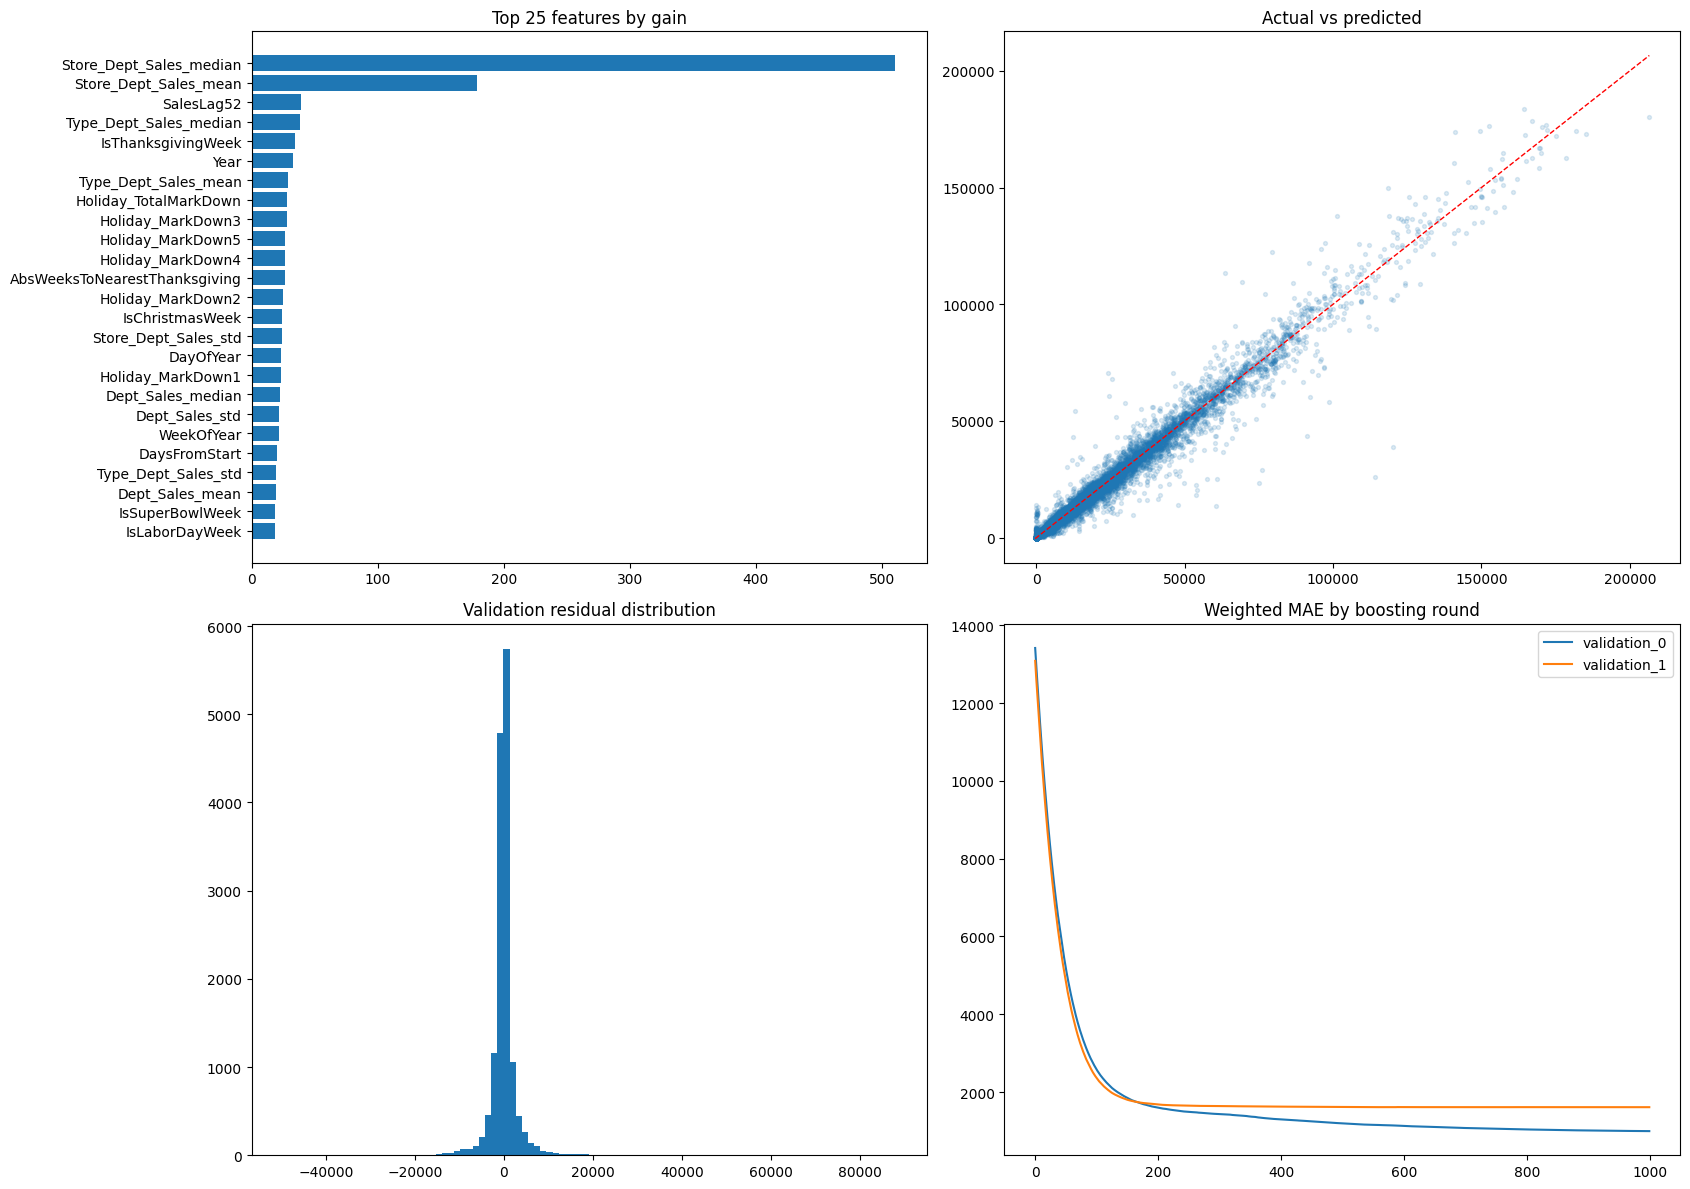

,feature,gain
0,Store_Dept_Sales_median,510.444580
1,Store_Dept_Sales_mean,178.900513
2,SalesLag52,38.913094
3,Type_Dept_Sales_median,38.527721
4,IsThanksgivingWeek,34.454632
5,Year,32.712978
6,Type_Dept_Sales_mean,28.672062
7,Holiday_TotalMarkDown,27.998964
8,Holiday_MarkDown3,27.912550
9,Holiday_MarkDown5,26.441568


,Dept,wmae,mae,rows
57,65,10913.819253,10045.989492,32.0
37,39,10354.081898,11615.529902,9.0
60,72,6866.623796,6012.529027,1358.0
36,38,6520.302606,6492.195251,1440.0
73,92,5268.268314,5108.080677,1440.0
76,95,4200.251421,4039.187184,1440.0
0,1,3689.339343,3995.821162,1440.0
14,16,3575.415659,3844.212061,1440.0
71,90,3321.071841,3288.328873,1440.0
4,5,3114.676529,3129.597862,1440.0


In [69]:
validation_results = valid_part[["Store", "Dept", "Date", "IsHoliday", "Weekly_Sales"]].copy()
validation_results["Prediction"] = valid_pred
validation_results["Residual"] = validation_results["Weekly_Sales"] - validation_results["Prediction"]
validation_results["AbsoluteError"] = validation_results["Residual"].abs()
validation_results["Week"] = validation_results["Date"].dt.strftime("%Y-%m-%d")

weekly_metrics = validation_results.groupby("Date").apply(
    lambda g: pd.Series({
        "wmae": weighted_mae(g.Weekly_Sales, g.Prediction, g.IsHoliday),
        "mae": mean_absolute_error(g.Weekly_Sales, g.Prediction),
        "rows": len(g),
    }),
    include_groups=False,
).reset_index()

dept_metrics = validation_results.groupby("Dept").apply(
    lambda g: pd.Series({
        "wmae": weighted_mae(g.Weekly_Sales, g.Prediction, g.IsHoliday),
        "mae": mean_absolute_error(g.Weekly_Sales, g.Prediction),
        "rows": len(g),
    }),
    include_groups=False,
).reset_index().sort_values("wmae", ascending=False)

booster_scores = model.get_booster().get_score(importance_type="gain")
importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "gain": [booster_scores.get(name, 0.0) for name in FEATURE_COLUMNS],
}).sort_values("gain", ascending=False).reset_index(drop=True)

evals = model.evals_result()
learning_curve = pd.DataFrame({
    dataset: values[CONFIG["eval_metric"]] for dataset, values in evals.items()
})
learning_curve.index.name = "boosting_round"
learning_curve = learning_curve.reset_index()

sample = validation_results.sample(min(15000, len(validation_results)), random_state=SEED)
fig, axes = plt.subplots(2, 2, figsize=(17, 12))
top = importance.head(25).sort_values("gain")
axes[0, 0].barh(top.feature, top.gain)
axes[0, 0].set_title("Top 25 features by gain")
axes[0, 1].scatter(sample.Weekly_Sales, sample.Prediction, alpha=0.15, s=8)
limits = [sample[["Weekly_Sales", "Prediction"]].min().min(), sample[["Weekly_Sales", "Prediction"]].max().max()]
axes[0, 1].plot(limits, limits, "r--", linewidth=1)
axes[0, 1].set_title("Actual vs predicted")
axes[1, 0].hist(sample.Residual, bins=100)
axes[1, 0].set_title("Validation residual distribution")
for dataset in [c for c in learning_curve.columns if c != "boosting_round"]:
    axes[1, 1].plot(learning_curve.boosting_round, learning_curve[dataset], label=dataset)
axes[1, 1].set_title("Weighted MAE by boosting round")
axes[1, 1].legend()
plt.tight_layout()

run.log({
    "diagnostics/overview": wandb.Image(fig),
    "diagnostics/feature_importance": wandb.Table(dataframe=importance),
    "diagnostics/weekly_metrics": wandb.Table(dataframe=weekly_metrics),
    "diagnostics/department_metrics": wandb.Table(dataframe=dept_metrics),
    "diagnostics/learning_curve": wandb.Table(dataframe=learning_curve),
    "diagnostics/prediction_sample": wandb.Table(dataframe=sample.assign(Date=sample.Date.astype(str))),
})
plt.show()

display(importance.head(25))
display(dept_metrics.head(15))

## Save and log the reproducible validation bundle

In [70]:
validation_model_path = OUTPUT_DIR / "xgboost_engineered_validation.json"
known_transformer_path = OUTPUT_DIR / "known_feature_transformer.joblib"
aggregate_encoder_path = OUTPUT_DIR / "target_aggregate_encoder.joblib"
importance_path = OUTPUT_DIR / "feature_importance.csv"
metrics_path = OUTPUT_DIR / "validation_metrics.json"
validation_predictions_path = OUTPUT_DIR / "validation_predictions.csv"
config_path = OUTPUT_DIR / "experiment_config.json"

model.save_model(validation_model_path)
joblib.dump(known_transformer, known_transformer_path)
joblib.dump(aggregate_encoder, aggregate_encoder_path)
importance.to_csv(importance_path, index=False)
metrics_path.write_text(json.dumps(metrics, indent=2))
config_path.write_text(json.dumps({**CONFIG, **BEST_PARAMS, **split_summary}, indent=2, default=str))
if CONFIG["log_full_validation_predictions"]:
    validation_results.to_csv(validation_predictions_path, index=False)

model_artifact = wandb.Artifact(
    f"{EXPERIMENT_ID}-validation-model",
    type="model",
    description="Leakage-safe engineered XGBoost model selected by Optuna on a chronological split.",
    metadata={**metrics, **split_summary, "best_params": BEST_PARAMS},
)
for path in [
    validation_model_path, known_transformer_path, aggregate_encoder_path,
    feature_manifest_path, importance_path, metrics_path, config_path,
]:
    model_artifact.add_file(str(path))
if CONFIG["log_full_validation_predictions"]:
    model_artifact.add_file(str(validation_predictions_path))
run.log_artifact(model_artifact, aliases=["validation", "best", "latest"])
run.finish()
print(f"Validation bundle saved to {OUTPUT_DIR}")

baseline/median_wmae,▁
best_iteration,▁
best_score,▁
epoch,▁▁▁▁▁▁▂▂▂▂▂▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇████
model/best_iteration,▁
model/best_score,▁
validation/holiday_mae,▁
validation/improvement_over_median_pct,▁
validation/mae,▁
validation/non_holiday_mae,▁
+4,...


Validation bundle saved to /content/artifacts/xgboost_engineered


## Optional full-data refit, Kaggle submission, and production-candidate artifact

The full-data refit repeats every fitted preprocessing step on all labeled rows, uses the validation model's best tree count, then predicts the 39-week test horizon. `lag_52` test values are joined only from observed training sales.

In [71]:
if CONFIG["run_final_refit"]:
    final_run = wandb.init(
        entity=WANDB_ENTITY,
        project=WANDB_PROJECT,
        name=f"{EXPERIMENT_ID}-full-refit",
        group=EXPERIMENT_ID,
        job_type="full-refit",
        # Updated to use ORGANIZATION_CONFIG
        tags=["xgboost", "full-data", "submission"] + ORGANIZATION_CONFIG.get("tags", []),
        notes=ORGANIZATION_CONFIG.get("notes", ""),
        config={**CONFIG, **BEST_PARAMS, "selected_estimators": int(model.best_iteration) + 1},
        save_code=True,
    )

    final_known_transformer = WalmartKnownFeatureTransformer()
    full_engineered = final_known_transformer.fit_transform(train_merged)
    test_engineered = final_known_transformer.transform(test_merged)
    full_engineered = add_safe_lag_52(full_engineered, train_merged)
    test_engineered = add_safe_lag_52(test_engineered, train_merged)

    final_aggregate_encoder = TimeSafeTargetAggregateEncoder()
    full_engineered = final_aggregate_encoder.fit_transform(
        full_engineered, full_engineered["Weekly_Sales"]
    )
    test_engineered = final_aggregate_encoder.transform(test_engineered)
    X_full, final_features = model_matrix(full_engineered)
    X_test, _ = model_matrix(test_engineered, final_features)
    assert final_features == FEATURE_COLUMNS

    final_rounds = int(model.best_iteration) + 1
    final_model = make_model(
        BEST_PARAMS,
        n_estimators=final_rounds,
        early_stopping=False,
    )
    final_weights = competition_weights(full_engineered["IsHoliday"])
    final_model.fit(
        X_full,
        full_engineered["Weekly_Sales"],
        sample_weight=final_weights,
        verbose=False,
    )
    test_pred = final_model.predict(X_test)
    submission = pd.DataFrame({
        "Id": (
            test_merged["Store"].astype(str) + "_"
            + test_merged["Dept"].astype(str) + "_"
            + test_merged["Date"].dt.strftime("%Y-%m-%d")
        ),
        "Weekly_Sales": test_pred,
    })
    assert len(submission) == len(test_raw)
    assert submission["Id"].is_unique
    assert np.isfinite(submission["Weekly_Sales"]).all()

    final_model_path = OUTPUT_DIR / "xgboost_engineered_final.json"
    final_known_path = OUTPUT_DIR / "final_known_feature_transformer.joblib"
    final_aggregate_path = OUTPUT_DIR / "final_target_aggregate_encoder.joblib"
    submission_path = OUTPUT_DIR / "submission_xgboost_engineered.csv"
    final_model.save_model(final_model_path)
    joblib.dump(final_known_transformer, final_known_path)
    joblib.dump(final_aggregate_encoder, final_aggregate_path)
    submission.to_csv(submission_path, index=False)

    final_run.log({
        "final/training_rows": len(X_full),
        "final/test_rows": len(X_test),
        "final/n_estimators": final_rounds,
        "final/test_lag52_coverage": float(test_engineered["SalesLag52_available"].mean()),
        "final/prediction_mean": float(np.mean(test_pred)),
        "final/prediction_std": float(np.std(test_pred)),
        "final/prediction_min": float(np.min(test_pred)),
        "final/prediction_max": float(np.max(test_pred)),
        "final/submission_sample": wandb.Table(dataframe=submission.head(1000)),
    })
    final_artifact = wandb.Artifact(
        f"{EXPERIMENT_ID}-production-candidate",
        type="model",
        metadata={
            "n_estimators": final_rounds,
            "training_rows": len(X_full),
            "feature_count": len(final_features),
            "test_lag52_coverage": float(test_engineered["SalesLag52_available"].mean()),
            "best_params": BEST_PARAMS,
        },
    )
    for path in [
        final_model_path, final_known_path, final_aggregate_path,
        feature_manifest_path, config_path, submission_path,
    ]:
        final_artifact.add_file(str(path))
    final_run.log_artifact(final_artifact, aliases=["production-candidate", "latest"])
    final_run.finish()
    display(submission.head())
    print(f"Submission saved to {submission_path}")
else:
    print("Final refit skipped. Set CONFIG['run_final_refit'] = True to create a submission.")

final/n_estimators,▁
final/prediction_max,▁
final/prediction_mean,▁
final/prediction_min,▁
final/prediction_std,▁
final/test_lag52_coverage,▁
final/test_rows,▁
final/training_rows,▁
final/n_estimators,1000
final/prediction_max,288207.4375
final/prediction_mean,16148.62402


,Id,Weekly_Sales
0,1_1_2012-11-02,37984.878906
1,1_2_2012-11-02,46311.750000
2,1_3_2012-11-02,9618.943359
3,1_4_2012-11-02,38975.890625
4,1_5_2012-11-02,27375.708984


Submission saved to /content/artifacts/xgboost_engineered/submission_xgboost_engineered.csv


## Package a pipeline that accepts raw test rows

The fitted transformer below owns the external feature table, store metadata, training sales history, imputation values, target-aggregate mappings, and final feature order. Therefore `registered_pipeline.predict(raw_test)` performs all preprocessing internally. The already-trained `final_model` is reused; this cell does not train XGBoost again.

In [ ]:
class RawWalmartFeatureTransformer(BaseEstimator, TransformerMixin):
    """Convert raw train/test.csv rows into the final XGBoost matrix."""

    def __init__(self, external_features: pd.DataFrame, stores: pd.DataFrame):
        self.external_features = external_features
        self.stores = stores

    def _merge(self, X: pd.DataFrame) -> pd.DataFrame:
        frame = X.copy()
        frame["__input_order"] = np.arange(len(frame))
        frame["Date"] = pd.to_datetime(frame["Date"])
        external = self.external_features.copy()
        external["Date"] = pd.to_datetime(external["Date"])
        external = external.drop(columns="IsHoliday", errors="ignore")
        merged = frame.merge(
            external,
            on=["Store", "Date"],
            how="left",
            validate="many_to_one",
        )
        merged = merged.merge(
            self.stores,
            on="Store",
            how="left",
            validate="many_to_one",
        )
        return (
            merged.sort_values("__input_order")
            .drop(columns="__input_order")
            .reset_index(drop=True)
        )

    def fit_transform(self, X: pd.DataFrame, y=None, **fit_params) -> pd.DataFrame:
        if y is None:
            raise ValueError("Training Weekly_Sales must be supplied as y.")
        sales = X.copy()
        sales["Weekly_Sales"] = np.asarray(y)
        merged = self._merge(sales)

        self.known_transformer_ = WalmartKnownFeatureTransformer()
        engineered = self.known_transformer_.fit_transform(merged)
        self.observed_history_ = merged[["Store", "Dept", "Date", "Weekly_Sales"]].copy()
        engineered = add_safe_lag_52(engineered, self.observed_history_)

        self.aggregate_encoder_ = TimeSafeTargetAggregateEncoder()
        engineered = self.aggregate_encoder_.fit_transform(
            engineered, engineered["Weekly_Sales"]
        )
        matrix, self.feature_columns_ = model_matrix(engineered)
        return matrix

    def fit(self, X: pd.DataFrame, y=None):
        self.fit_transform(X, y)
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        merged = self._merge(X)
        engineered = self.known_transformer_.transform(merged)
        engineered = add_safe_lag_52(engineered, self.observed_history_)
        engineered = self.aggregate_encoder_.transform(engineered)
        matrix, _ = model_matrix(engineered, self.feature_columns_)
        return matrix

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_columns_, dtype=object)


if not CONFIG["run_final_refit"]:
    raise RuntimeError("Set CONFIG['run_final_refit'] = True before packaging the registered pipeline.")

# Reuse the fitted preprocessing state and fitted final model from the full-refit cell.
raw_transformer = RawWalmartFeatureTransformer(features_raw, stores_raw)
raw_transformer.known_transformer_ = final_known_transformer
raw_transformer.aggregate_encoder_ = final_aggregate_encoder
raw_transformer.observed_history_ = train_merged[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].copy()
raw_transformer.feature_columns_ = final_features

registered_pipeline = Pipeline([
    ("feature_engineering", raw_transformer),
    ("xgboost", final_model),
])

# Contract test: raw predictions must match the manual path and preserve raw row order.
pipeline_test_pred = registered_pipeline.predict(test_raw)
raw_test_ids = (
    test_raw["Store"].astype(str) + "_"
    + test_raw["Dept"].astype(str) + "_"
    + test_raw["Date"].dt.strftime("%Y-%m-%d")
)
expected_pipeline_pred = raw_test_ids.map(
    submission.set_index("Id")["Weekly_Sales"]
).to_numpy()
np.testing.assert_allclose(
    pipeline_test_pred,
    expected_pipeline_pred,
    rtol=1e-6,
    atol=1e-4,
)
pipeline_columns = registered_pipeline.named_steps["feature_engineering"].transform(
    test_raw.head(100)
).columns.tolist()
assert pipeline_columns == final_features
print("Raw-input pipeline contract passed.")
print(f"Input columns: {test_raw.columns.tolist()}")
print(f"Output rows: {len(pipeline_test_pred):,}")

# Cloudpickle embeds notebook-defined classes, so inference needs no separate .py file.
raw_pipeline_path = OUTPUT_DIR / "walmart_xgboost_raw_pipeline.pkl"
with raw_pipeline_path.open("wb") as file:
    cloudpickle.dump(registered_pipeline, file)
with raw_pipeline_path.open("rb") as file:
    reloaded_pipeline = cloudpickle.load(file)
reloaded_pred = reloaded_pipeline.predict(test_raw.head(100))
np.testing.assert_allclose(reloaded_pred, pipeline_test_pred[:100], rtol=1e-6, atol=1e-4)

# A separate Python process has none of this notebook's class definitions.
smoke_input_path = OUTPUT_DIR / "pipeline_smoke_input.pkl"
test_raw.head(100).to_pickle(smoke_input_path)
smoke_script = "\n".join([
    "import cloudpickle, pandas as pd",
    f"with open({str(raw_pipeline_path)!r}, 'rb') as file:",
    "    pipeline = cloudpickle.load(file)",
    f"raw_input = pd.read_pickle({str(smoke_input_path)!r})",
    "predictions = pipeline.predict(raw_input)",
    "assert len(predictions) == len(raw_input)",
    "print('Fresh-process pipeline load passed.')",
])
subprocess.run([sys.executable, "-c", smoke_script], check=True)

WANDB_REGISTRY_PATH = "wandb-registry-model/Walmart_XGBoost_Pipeline"
registry_reference = {
    "entity": WANDB_ENTITY,
    "project": WANDB_PROJECT,
    "registry_path": WANDB_REGISTRY_PATH,
    "artifact_uri": f"{WANDB_REGISTRY_PATH}:champion",
    "alias": "champion",
    "pipeline_file": raw_pipeline_path.name,
}
registry_reference_path = OUTPUT_DIR / "wandb_registry_reference.json"
registry_reference_path.write_text(json.dumps(registry_reference, indent=2))

registry_run = wandb.init(
    entity=WANDB_ENTITY,
    project=WANDB_PROJECT,
    name=f"{EXPERIMENT_ID}-pipeline-registration",
    group=EXPERIMENT_ID,
    job_type="model-registration",
    tags=["xgboost", "raw-input-pipeline", "registry", "champion"],
    config={
        **CONFIG,
        **BEST_PARAMS,
        "feature_count": len(final_features),
        "n_estimators": final_rounds,
        "pipeline_input": "raw_test_csv",
    },
)
registry_run.log({
    **metrics,
    "pipeline/raw_input_contract_passed": 1,
    "pipeline/feature_count": len(final_features),
    "pipeline/test_rows_verified": len(pipeline_test_pred),
})

pipeline_artifact = wandb.Artifact(
    name="walmart-xgboost-raw-pipeline",
    type="model",
    description="Complete fitted XGBoost pipeline that accepts raw Walmart test.csv rows.",
    metadata={
        **metrics,
        "feature_count": len(final_features),
        "n_estimators": final_rounds,
        "raw_input_columns": test_raw.columns.tolist(),
        "includes_external_features": True,
        "includes_store_metadata": True,
        "includes_training_history": True,
    },
)
for artifact_path in [
    raw_pipeline_path,
    registry_reference_path,
    feature_manifest_path,
    config_path,
    metrics_path,
    importance_path,
]:
    pipeline_artifact.add_file(str(artifact_path))

logged_pipeline_artifact = registry_run.log_artifact(
    pipeline_artifact,
    aliases=["champion", "latest"],
)
logged_pipeline_artifact.wait()
registry_run.link_artifact(
    artifact=logged_pipeline_artifact,
    target_path=WANDB_REGISTRY_PATH,
    aliases=["champion", "latest"],
)
registry_run.summary["registry/path"] = WANDB_REGISTRY_PATH
registry_run.summary["registry/alias"] = "champion"
registry_run.finish()

display(pd.Series(registry_reference, name="value").to_frame())
print("Pipeline logged and linked to the W&B Model Registry.")

## Outputs

The W&B run group contains data lineage, diagnostics, tuning runs, artifacts, and a registered `Walmart_XGBoost_Pipeline` collection whose `champion` alias accepts raw `test.csv` rows directly.